## Do Lower-Income Adults Have Higher Obesity Rates? A Data Analysis Using CDC Surveillance Data

## INTRODUCTION

#### Backround & Public Health Significance

Obesity is one of the most pressing public health challenges facing the United States today. Defined as a body mass index (BMI) of 30 or higher, obesity is associated with increased risk of serious chronic conditions including type 2 diabetes, cardiovascular disease, hypertension, and certain cancers. According to the Centers for Disease Control and Prevention (CDC), more than 40% of American adults currently live with obesity, placing a significant burden on both individual health and the broader healthcare system. Understanding the social and economic factors that drive obesity rates is essential for developing effective public health interventions and reducing this burden across the population.

#### What We Know & Knowledge Gaps

Existing research has consistently identified socioeconomic status as an important determinant of health outcomes, including obesity. Studies have shown that individuals with lower incomes face greater exposure to obesogenic environments — including limited access to healthy foods, fewer opportunities for physical activity, and higher levels of chronic stress — all of which can contribute to weight gain over time. However, much of the existing literature relies on small regional samples or older data, and fewer studies have examined current national-level patterns using surveillance data collected directly by public health agencies. It remains important to regularly assess whether income-based disparities in obesity persist and to what degree they are reflected in contemporary population data.

#### Aims, Objectives & Hypothesis

The purpose of this study is to examine the relationship between income level and adult obesity rates in the United States using nationally representative data from the CDC's Nutrition, Physical Activity, and Obesity dataset. Specifically, this analysis compares obesity prevalence across income groups to determine whether lower-income adults experience disproportionately higher rates of obesity. We hypothesize that adults in lower income brackets will have significantly higher obesity rates compared to adults in higher income brackets, consistent with broader socioeconomic theories of health disparities. By using current CDC surveillance data, this study aims to provide an up-to-date, evidence-based picture of income-related obesity inequality at the national level.

#### BACKGROUND

#### PYTHON SETUP

In [9]:
# Import packages for numerical computation, statistics, plotting, and data wrangling
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd    
#Import seaborn for plotting
import seaborn as sns


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# CDC Nutrition, Physical Activity, and Obesity dataset — direct download
url = "https://data.cdc.gov/api/views/hn4x-zwk7/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# Preview what we have
print(df.shape)
print(df.columns.tolist())

(110880, 33)
['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'Datasource', 'Class', 'Topic', 'Question', 'Data_Value_Unit', 'Data_Value_Type', 'Data_Value', 'Data_Value_Alt', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit ', 'Sample_Size', 'Total', 'Age(years)', 'Education', 'Sex', 'Income', 'Race/Ethnicity', 'GeoLocation', 'ClassID', 'TopicID', 'QuestionID', 'DataValueTypeID', 'LocationID', 'StratificationCategory1', 'Stratification1', 'StratificationCategoryId1', 'StratificationID1']


/tmp/ipykernel_10484/644708765.py:7: DtypeWarning: Columns (0: Data_Value_Unit) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


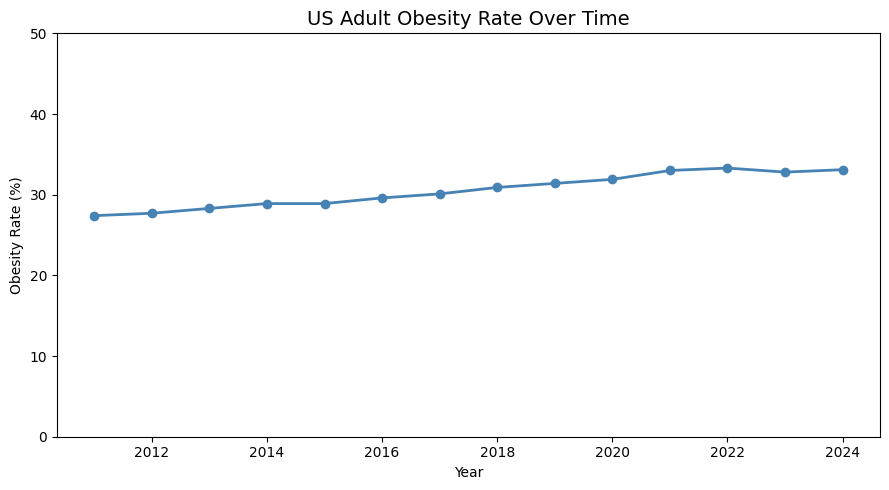

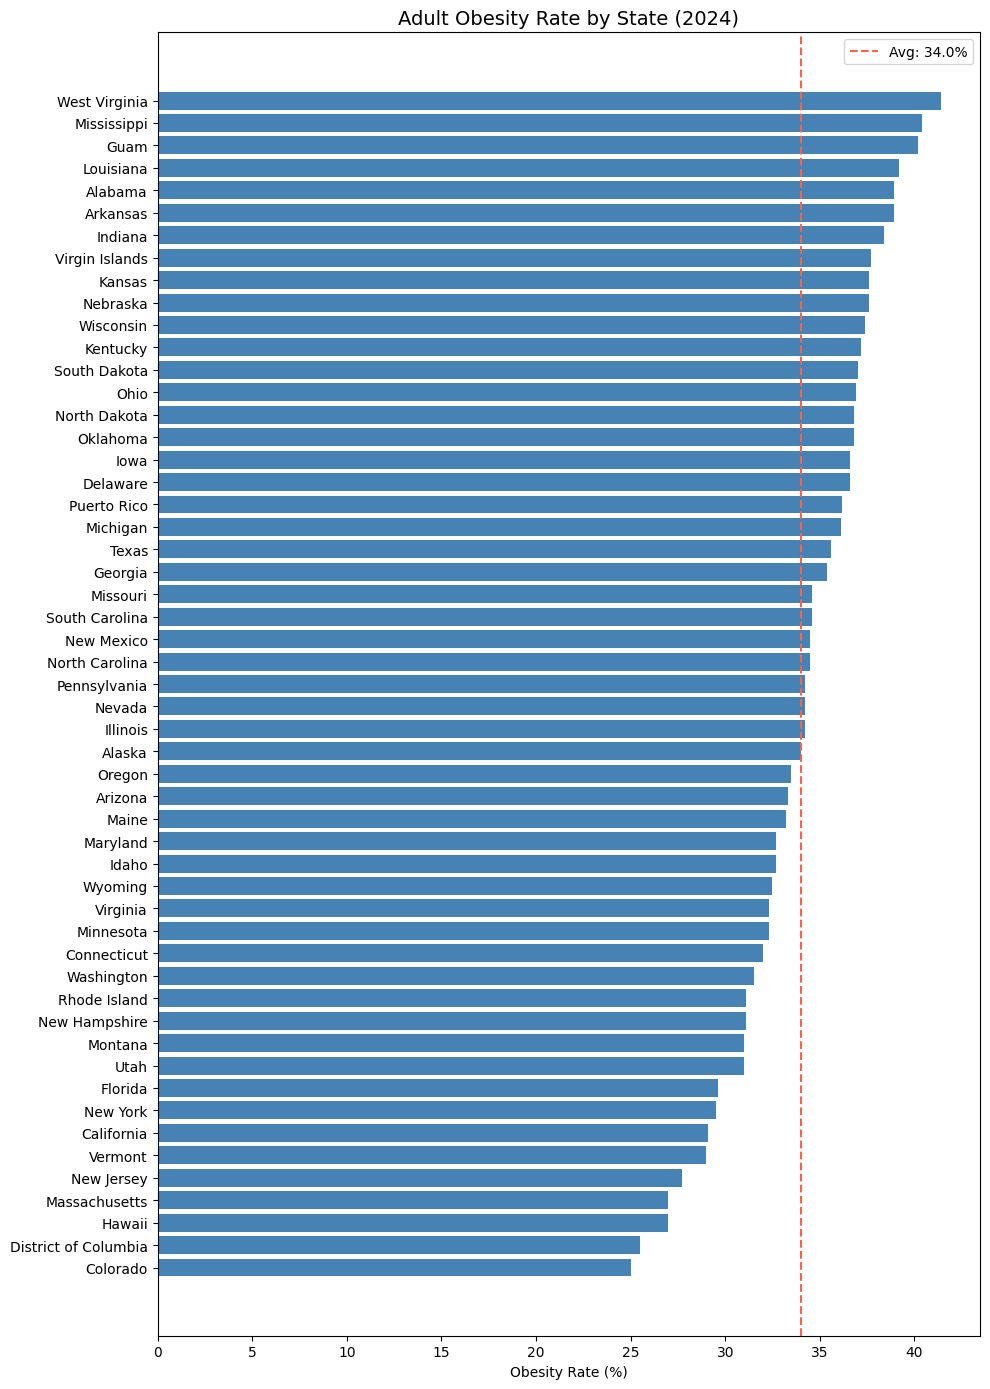

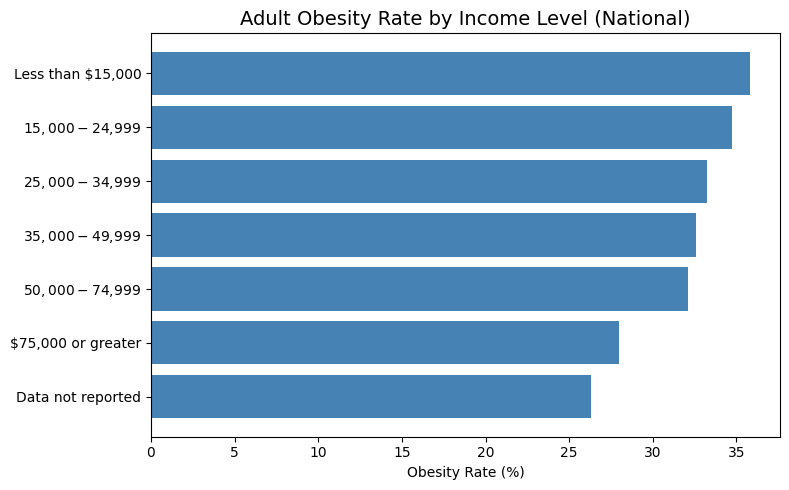

Done! You made 3 charts:
  1. National obesity trend over time
  2. Obesity rate by state
  3. Obesity rate by income level


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Reload cleanly
url = "https://data.cdc.gov/api/views/hn4x-zwk7/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url, low_memory=False)

# Filter to obesity rates at the national/state level, overall population (no subgroup)
obesity = df[
    (df['Topic'] == 'Obesity / Weight Status') &
    (df['Question'] == 'Percent of adults aged 18 years and older who have obesity') &
    (df['StratificationCategory1'] == 'Total') &
    (df['Data_Value_Type'] == 'Value')
].copy()

obesity['Data_Value'] = pd.to_numeric(obesity['Data_Value'], errors='coerce')
obesity = obesity.dropna(subset=['Data_Value'])

# --- Plot 1: Obesity rate over time (national trend) ---
national = obesity[obesity['LocationDesc'] == 'National']
by_year = national.groupby('YearStart')['Data_Value'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(by_year['YearStart'], by_year['Data_Value'], marker='o', color='steelblue', linewidth=2)
ax.set_title('US Adult Obesity Rate Over Time', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Obesity Rate (%)')
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()

# --- Plot 2: Obesity rate by state (most recent year) ---
latest_year = obesity['YearStart'].max()
by_state = obesity[
    (obesity['YearStart'] == latest_year) &
    (obesity['LocationDesc'] != 'National')
].groupby('LocationDesc')['Data_Value'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
bars = ax.barh(by_state.index, by_state.values, color='steelblue', edgecolor='none')
ax.axvline(by_state.mean(), color='tomato', linewidth=1.5, linestyle='--', label=f'Avg: {by_state.mean():.1f}%')
ax.set_title(f'Adult Obesity Rate by State ({latest_year})', fontsize=14)
ax.set_xlabel('Obesity Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 3: Obesity rate by income level ---
income = df[
    (df['Question'] == 'Percent of adults aged 18 years and older who have obesity') &
    (df['StratificationCategory1'] == 'Income') &
    (df['Data_Value_Type'] == 'Value') &
    (df['LocationDesc'] == 'National')
].copy()

income['Data_Value'] = pd.to_numeric(income['Data_Value'], errors='coerce')
income = income.dropna(subset=['Data_Value'])
by_income = income.groupby('Stratification1')['Data_Value'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(by_income.index, by_income.values, color='steelblue', edgecolor='none')
ax.set_title('Adult Obesity Rate by Income Level (National)', fontsize=14)
ax.set_xlabel('Obesity Rate (%)')
plt.tight_layout()
plt.show()

print("Done! You made 3 charts:")
print("  1. National obesity trend over time")
print("  2. Obesity rate by state")
print("  3. Obesity rate by income level")

#### METHODS

#### RESULTS

#### DATA IMPORT AND VISUALIZATION

#### EXPLORATORY DATA ANALYSIS

In [13]:
# Calculate summary statistics for the most recent year
print("Summary statistics for obesity rates by state in the most recent year:")
print(by_state.describe())

Summary statistics for obesity rates by state in the most recent year:
count    53.000000
mean     34.024528
std       3.895506
min      25.000000
25%      31.500000
50%      34.200000
75%      36.900000
max      41.400000
Name: Data_Value, dtype: float64


In [17]:
stats.iqr(df['Data_Value'].dropna())

np.float64(12.5)

In [18]:
# calculate summary statistics of the state column for each year
state_stats = obesity.groupby('YearStart')['Data_Value'].describe()
print(state_stats)

           count       mean       std   min     25%    50%     75%   max
YearStart                                                               
2011        52.0  27.588462  3.012565  20.7  25.325  27.75  29.600  34.9
2012        52.0  27.936538  3.341423  20.5  25.675  27.65  29.875  34.7
2013        53.0  28.630189  3.370265  21.3  26.400  28.90  31.000  35.1
2014        54.0  29.179630  3.325339  21.3  27.325  29.40  31.200  35.9
2015        54.0  29.322222  3.773426  20.2  26.325  29.80  31.550  36.2
2016        55.0  29.827273  3.624375  22.3  27.400  29.90  32.000  37.7
2017        54.0  30.701852  3.788189  22.6  28.175  31.45  33.150  38.1
2018        54.0  31.296296  3.795626  23.0  28.775  30.90  34.250  39.5
2019        53.0  32.052830  3.886149  23.8  29.500  32.30  34.800  40.8
2020        54.0  32.087037  3.996132  24.2  29.375  31.90  35.450  39.7
2021        54.0  33.537037  3.962432  24.7  31.000  33.90  36.075  40.6
2022        55.0  33.710909  3.913305  24.3  31.350